# Bank marketing exploration
Run scripts/download_data.py first. This notebook initially includes duration to demonstrate leakage, then removes it. The final model comparison and held-out test are in 02_model_comparison.ipynb.

In [1]:
from pathlib import Path
import os
ROOT = Path.cwd() if (Path.cwd() / "src/train.py").exists() else Path.cwd().parent
os.chdir(ROOT)


In [2]:
import pandas as pd

df = pd.read_csv(
    "data/bank-additional-full.csv",
    sep=";"
)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
for col in df.select_dtypes(include=["object", "string", "category"]).columns:
    print(col, df[col].value_counts().to_dict())

job {'admin.': 10422, 'blue-collar': 9254, 'technician': 6743, 'services': 3969, 'management': 2924, 'retired': 1720, 'entrepreneur': 1456, 'self-employed': 1421, 'housemaid': 1060, 'unemployed': 1014, 'student': 875, 'unknown': 330}
marital {'married': 24928, 'single': 11568, 'divorced': 4612, 'unknown': 80}
education {'university.degree': 12168, 'high.school': 9515, 'basic.9y': 6045, 'professional.course': 5243, 'basic.4y': 4176, 'basic.6y': 2292, 'unknown': 1731, 'illiterate': 18}
default {'no': 32588, 'unknown': 8597, 'yes': 3}
housing {'yes': 21576, 'no': 18622, 'unknown': 990}
loan {'no': 33950, 'yes': 6248, 'unknown': 990}
contact {'cellular': 26144, 'telephone': 15044}
month {'may': 13769, 'jul': 7174, 'aug': 6178, 'jun': 5318, 'nov': 4101, 'apr': 2632, 'oct': 718, 'sep': 570, 'mar': 546, 'dec': 182}
day_of_week {'thu': 8623, 'mon': 8514, 'wed': 8134, 'tue': 8090, 'fri': 7827}
poutcome {'nonexistent': 35563, 'failure': 4252, 'success': 1373}
y {'no': 36548, 'yes': 4640}


In [7]:
df["y"].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [8]:
baseline_accuracy = df["y"].value_counts(normalize=True).max()
baseline_accuracy

np.float64(0.8873458288821987)

In [9]:
df["target"] = df["y"].map({
    "no": 0,
    "yes": 1
})

df[["y", "target"]].head()


,y,target
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


In [10]:
X = df.drop(columns=["y", "target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41188, 20)
y shape: (41188,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (28831, 20) (28831,)
Validation: (6178, 20) (6178,)
Test: (6179, 20) (6179,)


In [12]:
print("Train positive rate:", y_train.mean())
print("Validation positive rate:", y_val.mean())
print("Test positive rate:", y_test.mean())

Train positive rate: 0.11265651555617218
Validation positive rate: 0.11265781806409841
Test positive rate: 0.11263958569347791


In [13]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

preprocessor

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['age', 'duration', 'campaign', 'pdays',
                                  'previous', 'emp.var.rate', 'cons.price.idx',
                                  'cons.conf.idx', 'euribor3m',
                                  'nr.employed']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'day_of_week', 'poutcome'])])

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [16]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [17]:
y_val_pred = logistic_model.predict(X_val)

y_val_pred[:20]

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [18]:
from sklearn.metrics import accuracy_score

val_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

val_accuracy

0.9138879896406604

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val,
    y_val_pred
)

cm

array([[5353,  129],
       [ 403,  293]])

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.6943127962085308
Recall: 0.4209770114942529
F1: 0.5241502683363148


In [21]:
y_val_prob = logistic_model.predict_proba(X_val)[:, 1]

y_val_prob[:20]


array([0.0098381 , 0.03687193, 0.87963744, 0.0083296 , 0.0418042 ,
       0.0832594 , 0.01617676, 0.01062027, 0.01525633, 0.01676738,
       0.02500161, 0.02781459, 0.00997169, 0.2379917 , 0.02503878,
       0.85254483, 0.03071125, 0.02974031, 0.02798653, 0.0117878 ])

In [22]:
threshold = 0.3

y_val_pred_03 = (
    y_val_prob >= threshold
).astype(int)

print(
    confusion_matrix(
        y_val,
        y_val_pred_03
    )
)

print(
    "Precision:",
    precision_score(
        y_val,
        y_val_pred_03
    )
)

print(
    "Recall:",
    recall_score(
        y_val,
        y_val_pred_03
    )
)

print(
    "F1:",
    f1_score(
        y_val,
        y_val_pred_03
    )
)

[[5195  287]
 [ 264  432]]
Precision: 0.6008344923504868
Recall: 0.6206896551724138
F1: 0.610600706713781


In [23]:
import pandas as pd

threshold_results = []

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    predictions = (
        y_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val,
            predictions
        ),
        "recall": recall_score(
            y_val,
            predictions
        ),
        "f1": f1_score(
            y_val,
            predictions
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df


,threshold,precision,recall,f1
0,0.1,0.425303,0.908046,0.579285
1,0.2,0.528942,0.761494,0.624264
2,0.3,0.600834,0.620690,0.610601
3,0.4,0.640074,0.495690,0.558704
4,0.5,0.694313,0.420977,0.524150
5,0.6,0.708861,0.321839,0.442688
6,0.7,0.733906,0.245690,0.368138


In [24]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

f1_scores = (
    2 * precisions[:-1] * recalls[:-1]
    / (precisions[:-1] + recalls[:-1] + 1e-12)
)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_precision = precisions[best_index]
best_recall = recalls[best_index]
best_f1 = f1_scores[best_index]

print("Best threshold:", best_threshold)
print("Best precision:", best_precision)
print("Best recall:", best_recall)
print("Best F1:", best_f1)

Best threshold: 0.2155714711022038
Best precision: 0.5431841831425598
Best recall: 0.75
Best F1: 0.6300543150266701


In [25]:
y_val_pred_best = (
    y_val_prob >= best_threshold
).astype(int)

confusion_matrix(
    y_val,
    y_val_pred_best
)

array([[5043,  439],
       [ 174,  522]])

In [26]:
comparison = pd.DataFrame({
    "metric": ["Precision", "Recall", "F1"],
    "threshold_0.5": [
        precision_score(y_val, y_val_pred),
        recall_score(y_val, y_val_pred),
        f1_score(y_val, y_val_pred)
    ],
    "best_threshold": [
        precision_score(y_val, y_val_pred_best),
        recall_score(y_val, y_val_pred_best),
        f1_score(y_val, y_val_pred_best)
    ]
})

comparison

,metric,threshold_0.5,best_threshold
0,Precision,0.694313,0.543184
1,Recall,0.420977,0.750000
2,F1,0.524150,0.630054


In [27]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)

pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9387056175487594
PR-AUC: 0.6276298870288938


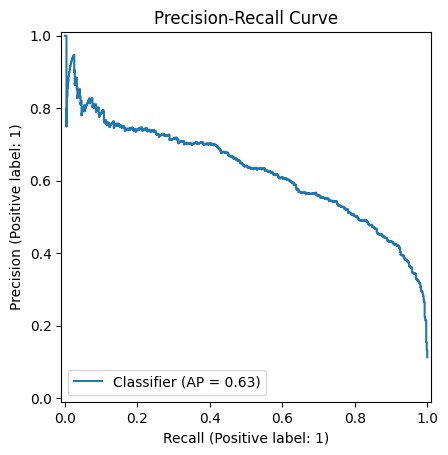

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_prob
)

plt.title("Precision-Recall Curve")
plt.show()

In [29]:
X_train_nd = X_train.drop(columns=["duration"])
X_val_nd = X_val.drop(columns=["duration"])
X_test_nd = X_test.drop(columns=["duration"])

In [30]:
numeric_features_nd = X_train_nd.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_nd = X_train_nd.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numeric features without duration:")
print(numeric_features_nd)

print("\nCategorical features:")
print(categorical_features_nd)

Numeric features without duration:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [31]:
preprocessor_nd = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features_nd
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_nd
        )
    ]
)

preprocessor_nd

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['age', 'campaign', 'pdays', 'previous',
                                  'emp.var.rate', 'cons.price.idx',
                                  'cons.conf.idx', 'euribor3m',
                                  'nr.employed']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'day_of_week', 'poutcome'])])

In [32]:
logistic_model_nd = Pipeline(
    steps=[
        ("preprocessor", preprocessor_nd),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model_nd.fit(
    X_train_nd,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [33]:
y_val_prob_nd = logistic_model_nd.predict_proba(
    X_val_nd
)[:, 1]

y_val_prob_nd[:20]

array([0.04624539, 0.06942053, 0.04293895, 0.04719964, 0.10957867,
       0.13334475, 0.05013543, 0.04095024, 0.05983558, 0.04890982,
       0.07394606, 0.10273151, 0.03380417, 0.24339943, 0.09320899,
       0.69454508, 0.05725605, 0.03407767, 0.04798938, 0.06785683])

In [34]:
roc_auc_nd = roc_auc_score(
    y_val,
    y_val_prob_nd
)

pr_auc_nd = average_precision_score(
    y_val,
    y_val_prob_nd
)

print("With duration:")
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("\nWithout duration:")
print("ROC-AUC:", roc_auc_nd)
print("PR-AUC:", pr_auc_nd)

With duration:
ROC-AUC: 0.9387056175487594
PR-AUC: 0.6276298870288938

Without duration:
ROC-AUC: 0.8021599948839883
PR-AUC: 0.4700697725957582


In [35]:
precisions_nd, recalls_nd, thresholds_nd = precision_recall_curve(
    y_val,
    y_val_prob_nd
)

f1_scores_nd = (
    2 * precisions_nd[:-1] * recalls_nd[:-1]
    / (
        precisions_nd[:-1]
        + recalls_nd[:-1]
        + 1e-12
    )
)

best_index_nd = np.argmax(f1_scores_nd)

best_threshold_nd = thresholds_nd[best_index_nd]
best_precision_nd = precisions_nd[best_index_nd]
best_recall_nd = recalls_nd[best_index_nd]
best_f1_nd = f1_scores_nd[best_index_nd]

print("Best threshold:", best_threshold_nd)
print("Best precision:", best_precision_nd)
print("Best recall:", best_recall_nd)
print("Best F1:", best_f1_nd)

Best threshold: 0.2207722911559955
Best precision: 0.46365914786967416
Best recall: 0.5316091954022989
Best F1: 0.4953145916996362


In [36]:
y_val_pred_best_nd = (
    y_val_prob_nd >= best_threshold_nd
).astype(int)

confusion_matrix(
    y_val,
    y_val_pred_best_nd
)

array([[5054,  428],
       [ 326,  370]])

In [37]:
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression with duration",
        "Logistic Regression without duration"
    ],
    "ROC_AUC": [
        roc_auc,
        roc_auc_nd
    ],
    "PR_AUC": [
        pr_auc,
        pr_auc_nd
    ],
    "best_threshold": [
        best_threshold,
        best_threshold_nd
    ],
    "precision": [
        best_precision,
        best_precision_nd
    ],
    "recall": [
        best_recall,
        best_recall_nd
    ],
    "F1": [
        best_f1,
        best_f1_nd
    ]
})

model_comparison

,model,ROC_AUC,PR_AUC,best_threshold,precision,recall,F1
0,Logistic Regression with duration,0.938706,0.62763,0.215571,0.543184,0.750000,0.630054
1,Logistic Regression without duration,0.802160,0.47007,0.220772,0.463659,0.531609,0.495315
